In [1]:
!nvidia-smi

Sun Dec  7 05:36:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install "protobuf>=4.25.3,<5.0.0" --force-reinstall

  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import time
import psutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\nGPU detected: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  - {gpu}")
else:
    print("\n⚠️ WARNING: No GPU detected! Please enable T4 GPU in Runtime > Change runtime type")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU detected: 1 device(s)
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE_TUNE = 40
DATA_DIR = '/content/drive/MyDrive/dataset-resized'

print(f"Dataset directory: {DATA_DIR}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs (Frozen): {EPOCHS_FROZEN}")
print(f"Epochs (Fine-tune): {EPOCHS_FINE_TUNE}")
print(f"Total epochs: {EPOCHS_FROZEN + EPOCHS_FINE_TUNE}")

Dataset directory: /content/drive/MyDrive/dataset-resized
Image size: (224, 224)
Batch size: 32
Epochs (Frozen): 10
Epochs (Fine-tune): 40
Total epochs: 50


In [ ]:
# Create dataframe from directory structure
def create_dataframe(data_path):
    filepaths = []
    labels = []
    classes = sorted(os.listdir(data_path))

    print(f"Found {len(classes)} classes: {classes}")

    for label in classes:
        class_path = os.path.join(data_path, label)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    filepaths.append(os.path.join(class_path, img_file))
                    labels.append(label)

    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    print(f"\nTotal images: {len(df)}")
    print("\nClass distribution:")
    print(df['label'].value_counts())
    return df


full_df = create_dataframe(DATA_DIR)


train_df, temp_df = train_test_split(full_df, test_size=0.3, stratify=full_df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"\nTrain set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

Found 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Total images: 2527

Class distribution:
label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64

Train set: 1768 images
Validation set: 379 images
Test set: 380 images


In [ ]:

# MobileNetV2 specific preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # MobileNetV2 Specific (scales to [-1, 1])
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

print("\nTrain generator created:")
print(f"  - Batches per epoch: {len(train_generator)}")
print(f"  - Classes: {train_generator.class_indices}")

Found 1768 validated image filenames belonging to 6 classes.

Train generator created:
  - Batches per epoch: 56
  - Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [8]:
# Validation and test generators
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Validation generator created:")
print(f"  - Batches: {len(validation_generator)}")

Found 379 validated image filenames belonging to 6 classes.
Validation generator created:
  - Batches: 12


In [9]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Test generator created:")
print(f"  - Batches: {len(test_generator)}")

Found 380 validated image filenames belonging to 6 classes.
Test generator created:
  - Batches: 12


In [ ]:
# Build MobileNetV2 Model
from tensorflow.keras.layers import BatchNormalization, Activation

def build_mobilenetv2_model(num_classes):
    """
    Build MobileNetV2 model with custom head
    MobileNetV2 is designed for mobile and edge devices (lightweight)
    """
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Freeze base model initially

    # Custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

  
    x = Dense(512, use_bias=False)(x) 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return base_model, model


base_model, model = build_mobilenetv2_model(num_classes=6)

print("MobileNetV2 Model Built")
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]):,}")

MobileNetV2 Model Built

Total parameters: 2,918,470
Trainable parameters: 659,462
Non-trainable parameters: 2,259,008


In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,918,470 (11.13 MB)

 Trainable params: 659,462 (2.52 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [12]:
# --- STAGE 1: FROZEN BASE TRAINING ---
print("\n" + "="*80)
print("STAGE 1: Training with Frozen Base")
print("="*80)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Record training start time
start_time_frozen = time.time()

history_frozen = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks,
    verbose=1
)

# Record training end time
end_time_frozen = time.time()
training_time_frozen = end_time_frozen - start_time_frozen

print(f"\nStage 1 Training Time: {training_time_frozen:.2f} seconds ({training_time_frozen/60:.2f} minutes)")


STAGE 1: Training with Frozen Base


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5434 - loss: 1.3331 - val_accuracy: 0.7704 - val_loss: 0.7281 - learning_rate: 0.0010
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 594ms/step - accuracy: 0.8294 - loss: 0.4774 - val_accuracy: 0.8179 - val_loss: 0.5568 - learning_rate: 0.0010
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 602ms/step - accuracy: 0.8561 - loss: 0.3863 - val_accuracy: 0.8206 - val_loss: 0.5438 - learning_rate: 0.0010
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 573ms/step - accuracy: 0.8819 - loss: 0.3188 - val_accuracy: 0.8364 - val_loss: 0.4866 - learning_rate: 0.0010
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 575ms/step - accuracy: 0.9010 - loss: 0.2780 - val_accuracy: 0.8311 - val_loss: 0.5001 - learning_rate: 0.0010
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 595ms/step - accuracy: 0.9327 - loss: 0.1973 - val_accuracy: 0.8575 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 578ms/step - accuracy: 0.9306 - loss: 0.218

In [ ]:
# --- STAGE 2: FINE-TUNING WITH PARTIAL UNFREEZING ---
print("\n" + "="*80)
print("STAGE 2: Fine-tuning with Partial Unfreezing")
print("="*80)


base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable layers: {sum([layer.trainable for layer in base_model.layers])}")
print(f"\nTotal trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

model.compile(
    optimizer=Adam(learning_rate=1e-4),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Record fine-tuning start time
start_time_finetune = time.time()

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks,
    verbose=1
)

# Record fine-tuning end time
end_time_finetune = time.time()
training_time_finetune = end_time_finetune - start_time_finetune

print(f"\nStage 2 Training Time: {training_time_finetune:.2f} seconds ({training_time_finetune/60:.2f} minutes)")
print(f"\nTotal Training Time: {training_time_frozen + training_time_finetune:.2f} seconds ({(training_time_frozen + training_time_finetune)/60:.2f} minutes)")


STAGE 2: Fine-tuning with Partial Unfreezing
Total layers in base model: 154
Trainable layers: 30

Total trainable parameters: 2,185,862
Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 68s 892ms/step - accuracy: 0.8607 - loss: 0.3982 - val_accuracy: 0.8470 - val_loss: 0.5715 - learning_rate: 1.0000e-04
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 577ms/step - accuracy: 0.9093 - loss: 0.2396 - val_accuracy: 0.8549 - val_loss: 0.4983 - learning_rate: 1.0000e-04
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 602ms/step - accuracy: 0.9340 - loss: 0.1930 - val_accuracy: 0.8364 - val_loss: 0.5164 - learning_rate: 1.0000e-04
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 582ms/step - accuracy: 0.9450 - loss: 0.1511 - val_accuracy: 0.8364 - val_loss: 0.6065 - learning_rate: 1.0000e-04
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 610ms/step - accuracy: 0.9617 - loss: 0.1199 - val_accuracy: 0.8786 - val_loss: 0.4580 - learning_rate: 1.0000e-04
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 575ms/step - accuracy: 0.9662 - los

In [14]:
model.save('/content/drive/MyDrive/mobilenetv2_trashnet_model.h5')
print("Model saved to Google Drive!")

Model saved to Google Drive!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)

# Test set evaluation
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


EVALUATION ON TEST SET


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9067 - loss: 0.3411

Test Loss: 0.3143
Test Accuracy: 0.9158


In [ ]:
# Generate predictions
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.array(test_generator.classes)


class_labels = list(test_generator.class_indices.keys())

print(f"\nPredictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step

Predictions shape: (380, 6)
True labels shape: (380,)


In [20]:
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true, y_pred_classes, target_names=class_labels, digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard     0.9667    0.9667    0.9667        60
       glass     0.9221    0.9342    0.9281        76
       metal     0.8939    0.9516    0.9219        62
       paper     0.9032    0.9438    0.9231        89
     plastic     0.9242    0.8356    0.8777        73
       trash     0.8333    0.7500    0.7895        20

    accuracy                         0.9158       380
   macro avg     0.9072    0.8970    0.9011       380
weighted avg     0.9159    0.9158    0.9150       380



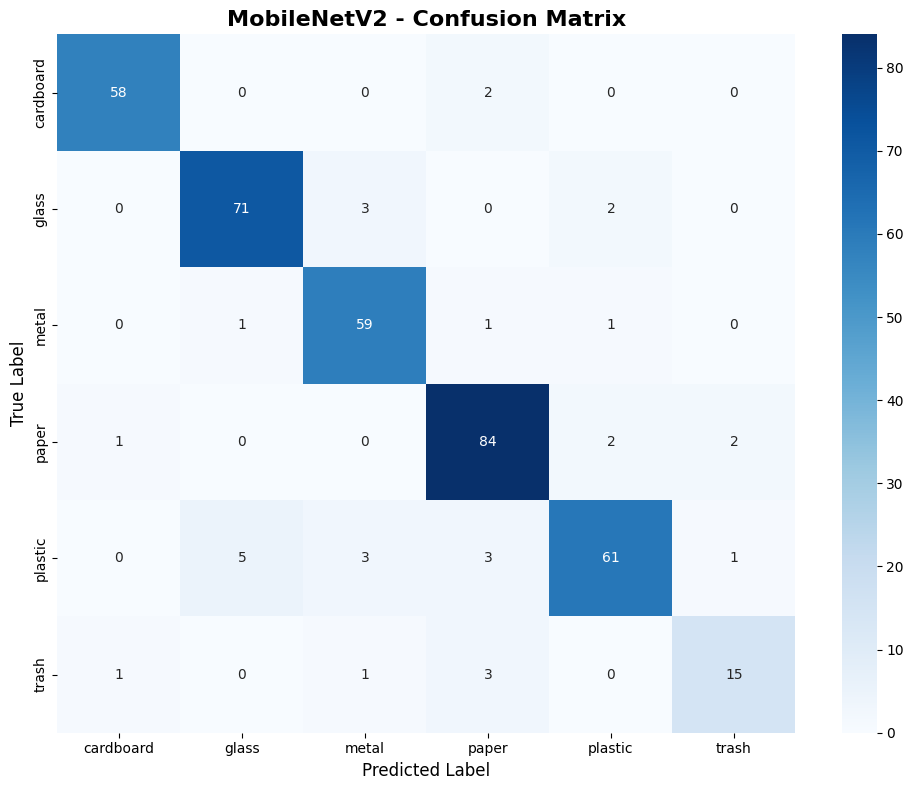

Confusion matrix saved to Google Drive!


In [21]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('MobileNetV2 - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mobilenetv2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to Google Drive!")

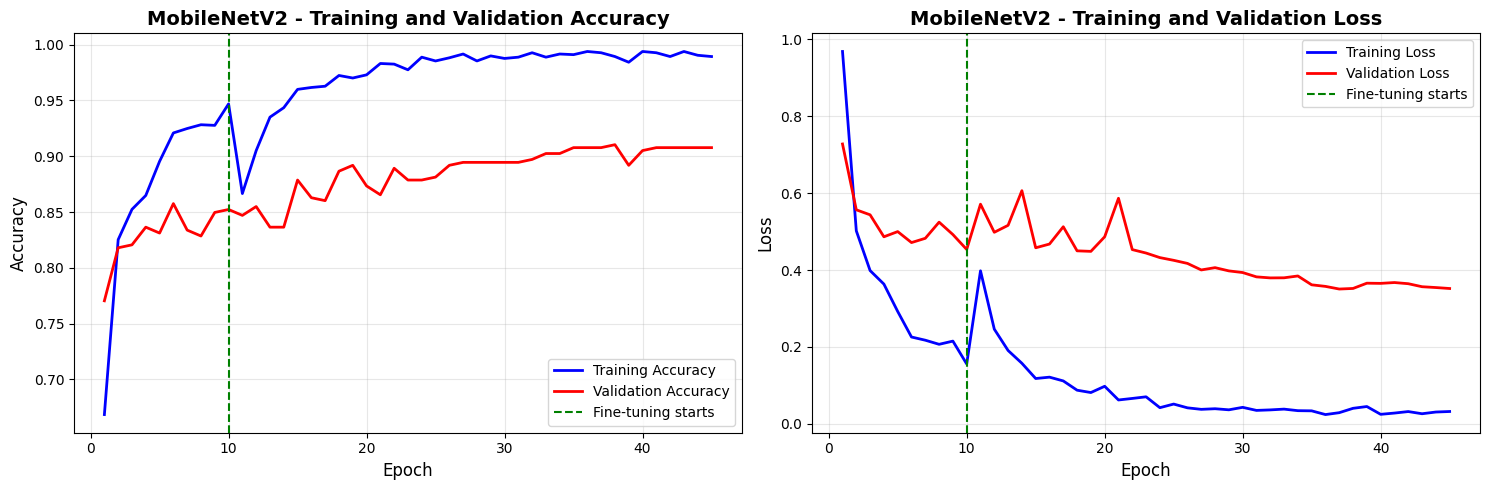

Training history plot saved to Google Drive!


In [22]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Combine histories
all_acc = history_frozen.history['accuracy'] + history_finetune.history['accuracy']
all_val_acc = history_frozen.history['val_accuracy'] + history_finetune.history['val_accuracy']
all_loss = history_frozen.history['loss'] + history_finetune.history['loss']
all_val_loss = history_frozen.history['val_loss'] + history_finetune.history['val_loss']

epochs_range = range(1, len(all_acc) + 1)

# Accuracy plot
axes[0].plot(epochs_range, all_acc, 'b-', label='Training Accuracy', linewidth=2)
axes[0].plot(epochs_range, all_val_acc, 'r-', label='Validation Accuracy', linewidth=2)
axes[0].axvline(x=EPOCHS_FROZEN, color='green', linestyle='--', linewidth=1.5, label='Fine-tuning starts')
axes[0].set_title('MobileNetV2 - Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, all_loss, 'b-', label='Training Loss', linewidth=2)
axes[1].plot(epochs_range, all_val_loss, 'r-', label='Validation Loss', linewidth=2)
axes[1].axvline(x=EPOCHS_FROZEN, color='green', linestyle='--', linewidth=1.5, label='Fine-tuning starts')
axes[1].set_title('MobileNetV2 - Training and Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mobilenetv2_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved to Google Drive!")

In [ ]:

print("\n" + "="*80)
print("INFERENCE TIME MEASUREMENT (GPU - T4)")
print("="*80)

# Measure inference time on GPU
test_generator.reset()
start_inference = time.time()
predictions_gpu = model.predict(test_generator, verbose=0)
end_inference = time.time()

total_inference_time = end_inference - start_inference
avg_inference_time = total_inference_time / len(test_df)

print(f"\nTotal inference time (GPU): {total_inference_time:.4f} seconds")
print(f"Average inference time per image (GPU): {avg_inference_time*1000:.4f} ms")
print(f"Images per second (GPU): {len(test_df)/total_inference_time:.2f}")


INFERENCE TIME MEASUREMENT (GPU - T4)

Total inference time (GPU): 2.8306 seconds
Average inference time per image (GPU): 7.4489 ms
Images per second (GPU): 134.25


In [ ]:
print("\n" + "="*80)
print("MODEL SIZE AND PARAMETERS")
print("="*80)


import os
temp_model_path = '/content/temp_mobilenetv2_model.h5'
model.save(temp_model_path)
model_size_bytes = os.path.getsize(temp_model_path)
model_size_mb = model_size_bytes / (1024 * 1024)

print(f"\nModel Size: {model_size_mb:.2f} MB")
print(f"Total Parameters: {model.count_params():,}")
print(f"Trainable Parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
print(f"Non-trainable Parameters: {sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]):,}")


os.remove(temp_model_path)


MODEL SIZE AND PARAMETERS

Model Size: 28.36 MB
Total Parameters: 2,918,470
Trainable Parameters: 2,185,862
Non-trainable Parameters: 732,608


In [ ]:

print("\n" + "="*80)
print("CPU INFERENCE TIME MEASUREMENT (Single Image)")
print("="*80)

test_generator.reset()
single_batch_x, single_batch_y = next(test_generator)
single_image = single_batch_x[:1]


print("Creating CPU model...")
with tf.device('/CPU:0'):
    
    cpu_base_model, cpu_model = build_mobilenetv2_model(num_classes=6)

    cpu_model.set_weights(model.get_weights())


    _ = cpu_model.predict(single_image, verbose=0)

   
    cpu_times = []
    for _ in range(10):
        start_cpu = time.time()
        _ = cpu_model.predict(single_image, verbose=0)
        end_cpu = time.time()
        cpu_times.append(end_cpu - start_cpu)

    avg_cpu_inference_time = np.mean(cpu_times)
    std_cpu_inference_time = np.std(cpu_times)

    print(f"\nSingle image inference time (CPU):")
    print(f"  Average: {avg_cpu_inference_time*1000:.4f} ms")
    print(f"  Std Dev: {std_cpu_inference_time*1000:.4f} ms")
    print(f"  Min: {min(cpu_times)*1000:.4f} ms")
    print(f"  Max: {max(cpu_times)*1000:.4f} ms")

# Clean up CPU model to free memory
del cpu_model, cpu_base_model


CPU INFERENCE TIME MEASUREMENT (Single Image)
Creating CPU model...

Single image inference time (CPU):
  Average: 575.3544 ms
  Std Dev: 132.2222 ms
  Min: 364.0604 ms
  Max: 679.1306 ms


In [ ]:
# --- SUMMARY REPORT ---
print("\n" + "="*80)
print("MOBILENETV2 FINAL SUMMARY REPORT")
print("="*80)

summary_report = f"""
MODEL: MobileNetV2 (Lightweight Architecture)
HARDWARE: Google Colab T4 GPU
DATASET: TrashNet (6 classes)

TRAINING:
  - Training images: {len(train_df)}
  - Validation images: {len(val_df)}
  - Test images: {len(test_df)}
  - Batch size: {BATCH_SIZE}
  - Total epochs: {len(all_acc)}
  - Stage 1 time (frozen): {training_time_frozen/60:.2f} minutes
  - Stage 2 time (fine-tune): {training_time_finetune/60:.2f} minutes
  - Total training time: {(training_time_frozen + training_time_finetune)/60:.2f} minutes

MODEL SPECIFICATIONS:
  - Total parameters: {model.count_params():,}
  - Model size: {model_size_mb:.2f} MB
  - Input size: {IMG_SIZE}

PERFORMANCE:
  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  - Test Loss: {test_loss:.4f}

INFERENCE SPEED:
  - GPU (T4) inference: {avg_inference_time*1000:.4f} ms/image
  - GPU throughput: {len(test_df)/total_inference_time:.2f} images/second
  - CPU inference: {avg_cpu_inference_time*1000:.4f} ms/image (single batch)

FILES SAVED TO GOOGLE DRIVE:
  ✓ mobilenetv2_trashnet_model.h5
  ✓ mobilenetv2_confusion_matrix.png
  ✓ mobilenetv2_training_history.png
"""

print(summary_report)


with open('/content/drive/MyDrive/mobilenetv2_summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\nSummary report saved to Google Drive!")


MOBILENETV2 FINAL SUMMARY REPORT

MODEL: MobileNetV2 (Lightweight Architecture)
HARDWARE: Google Colab T4 GPU
DATASET: TrashNet (6 classes)

TRAINING:
  - Training images: 1768
  - Validation images: 379
  - Test images: 380
  - Batch size: 32
  - Total epochs: 45
  - Stage 1 time (frozen): 6.41 minutes
  - Stage 2 time (fine-tune): 19.95 minutes
  - Total training time: 26.36 minutes

MODEL SPECIFICATIONS:
  - Total parameters: 2,918,470
  - Model size: 28.36 MB
  - Input size: (224, 224)

PERFORMANCE:
  - Test Accuracy: 0.9158 (91.58%)
  - Test Loss: 0.3143

INFERENCE SPEED:
  - GPU (T4) inference: 7.4489 ms/image
  - GPU throughput: 134.25 images/second
  - CPU inference: 575.3544 ms/image (single batch)

FILES SAVED TO GOOGLE DRIVE:
  ✓ mobilenetv2_trashnet_model.h5
  ✓ mobilenetv2_confusion_matrix.png
  ✓ mobilenetv2_training_history.png


Summary report saved to Google Drive!


In [ ]:
# --- PER-CLASS PERFORMANCE TABLE ---
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred_classes, labels=range(len(class_labels))
)

per_class_df = pd.DataFrame({
    'Class': class_labels,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n" + "="*80)
print("PER-CLASS PERFORMANCE")
print("="*80)
print(per_class_df.to_string(index=False))


per_class_df.to_csv('/content/drive/MyDrive/mobilenetv2_per_class_performance.csv', index=False)
print("\nPer-class performance saved to Google Drive!")


PER-CLASS PERFORMANCE
    Class  Precision   Recall  F1-Score  Support
cardboard   0.966667 0.966667  0.966667       60
    glass   0.922078 0.934211  0.928105       76
    metal   0.893939 0.951613  0.921875       62
    paper   0.903226 0.943820  0.923077       89
  plastic   0.924242 0.835616  0.877698       73
    trash   0.833333 0.750000  0.789474       20

Per-class performance saved to Google Drive!
